In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("smartcart_customers.csv")

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Missing data

In [7]:
df["Income"] = df["Income"].fillna(df["Income"].median())

# Feature Engineering

In [10]:
df["Age"] = 2026 - df["Year_Birth"]

In [28]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"] , dayfirst=True)   # pandas accept month-day-year

refer_data = df["Dt_Customer"].max()

df["Customer_tenure_days"] = (refer_data-df["Dt_Customer"]).dt.days

In [29]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_days', 'Total_spending',
       'Total_childrens'],
      dtype='object')

In [30]:
df["Total_spending"] = df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [31]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spending,Total_childrens
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [84]:
# children

df["Total_childrens"] = df["Kidhome"]+df["Teenhome"]

KeyError: 'Kidhome'

In [23]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spending,Total_childrens
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [36]:
# status

df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [39]:
df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate" , "2n Cycle":"Undergraduate",
    "Master":"Postgraduate","PhD":"Postgraduate",
    "Graduation" :"Graduate"
    
})

In [41]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [ ]:
df["Marital_Status"] = df["Marital_Status"].replace({
    "Married":"Partner" ,"Together":"Partner",
    "Single":"Alone","Divorced":"Alone", "Widow":"Alone","Absurd":"Alone", "YOLO":"Alone"    
})

# droping the columns

In [55]:
remove_column=["ID" , "Year_Birth" ,"Kidhome" ,"Teenhome" ,"MntWines","MntFruits" ,"MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

df = df.drop(columns=remove_column , axis=1)
df = df.drop(columns=["Dt_Customer"] , axis=1)

In [58]:
df = df.drop(columns=["Dt_Customer"] , axis=1)

In [59]:
df.shape

(2240, 15)

# Outliers

In [64]:
col = [ 'Income', 'Recency', 'Response', 'Age','Total_spending', 'Total_childrens']

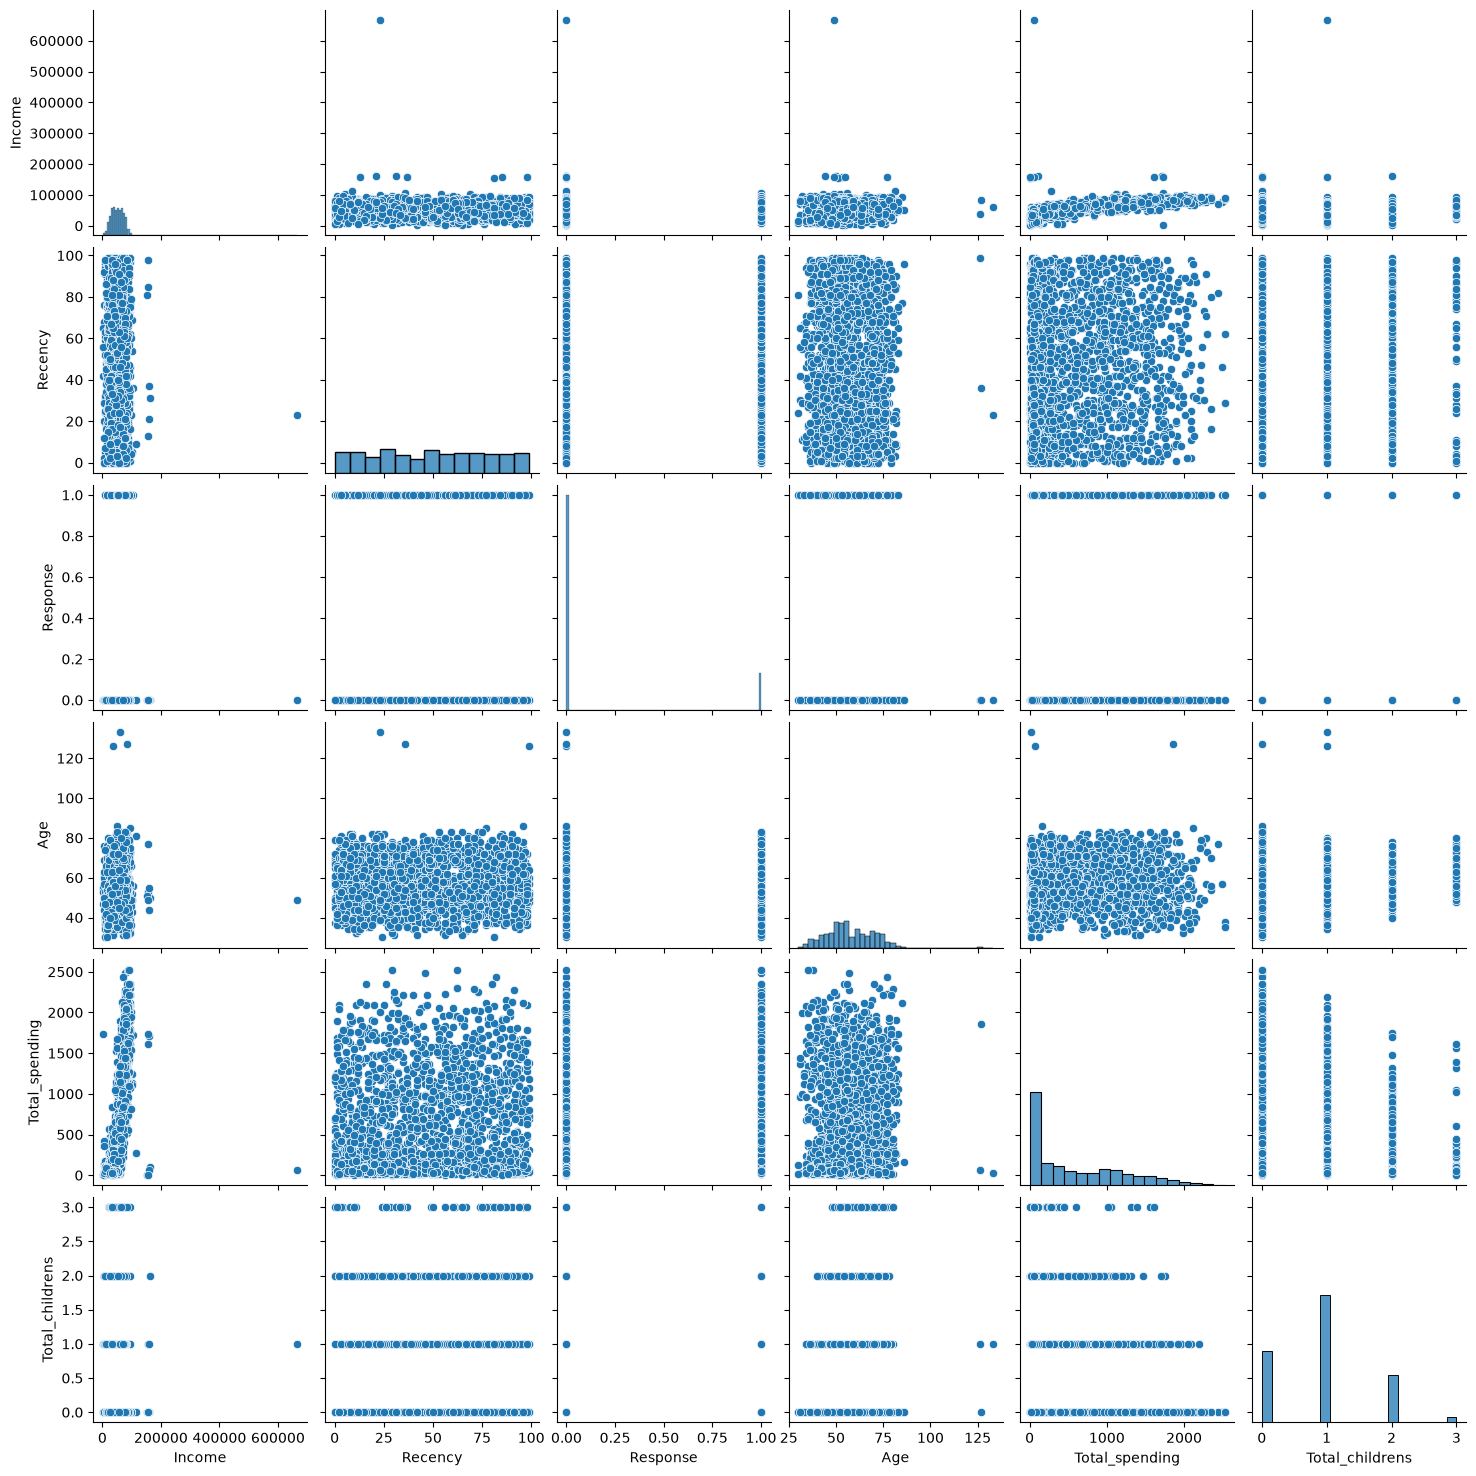

In [65]:
sns.pairplot(df[col])

In [73]:
df = df[(df["Age"] < 90)]
df = df[(df["Income"] < 600_000)]

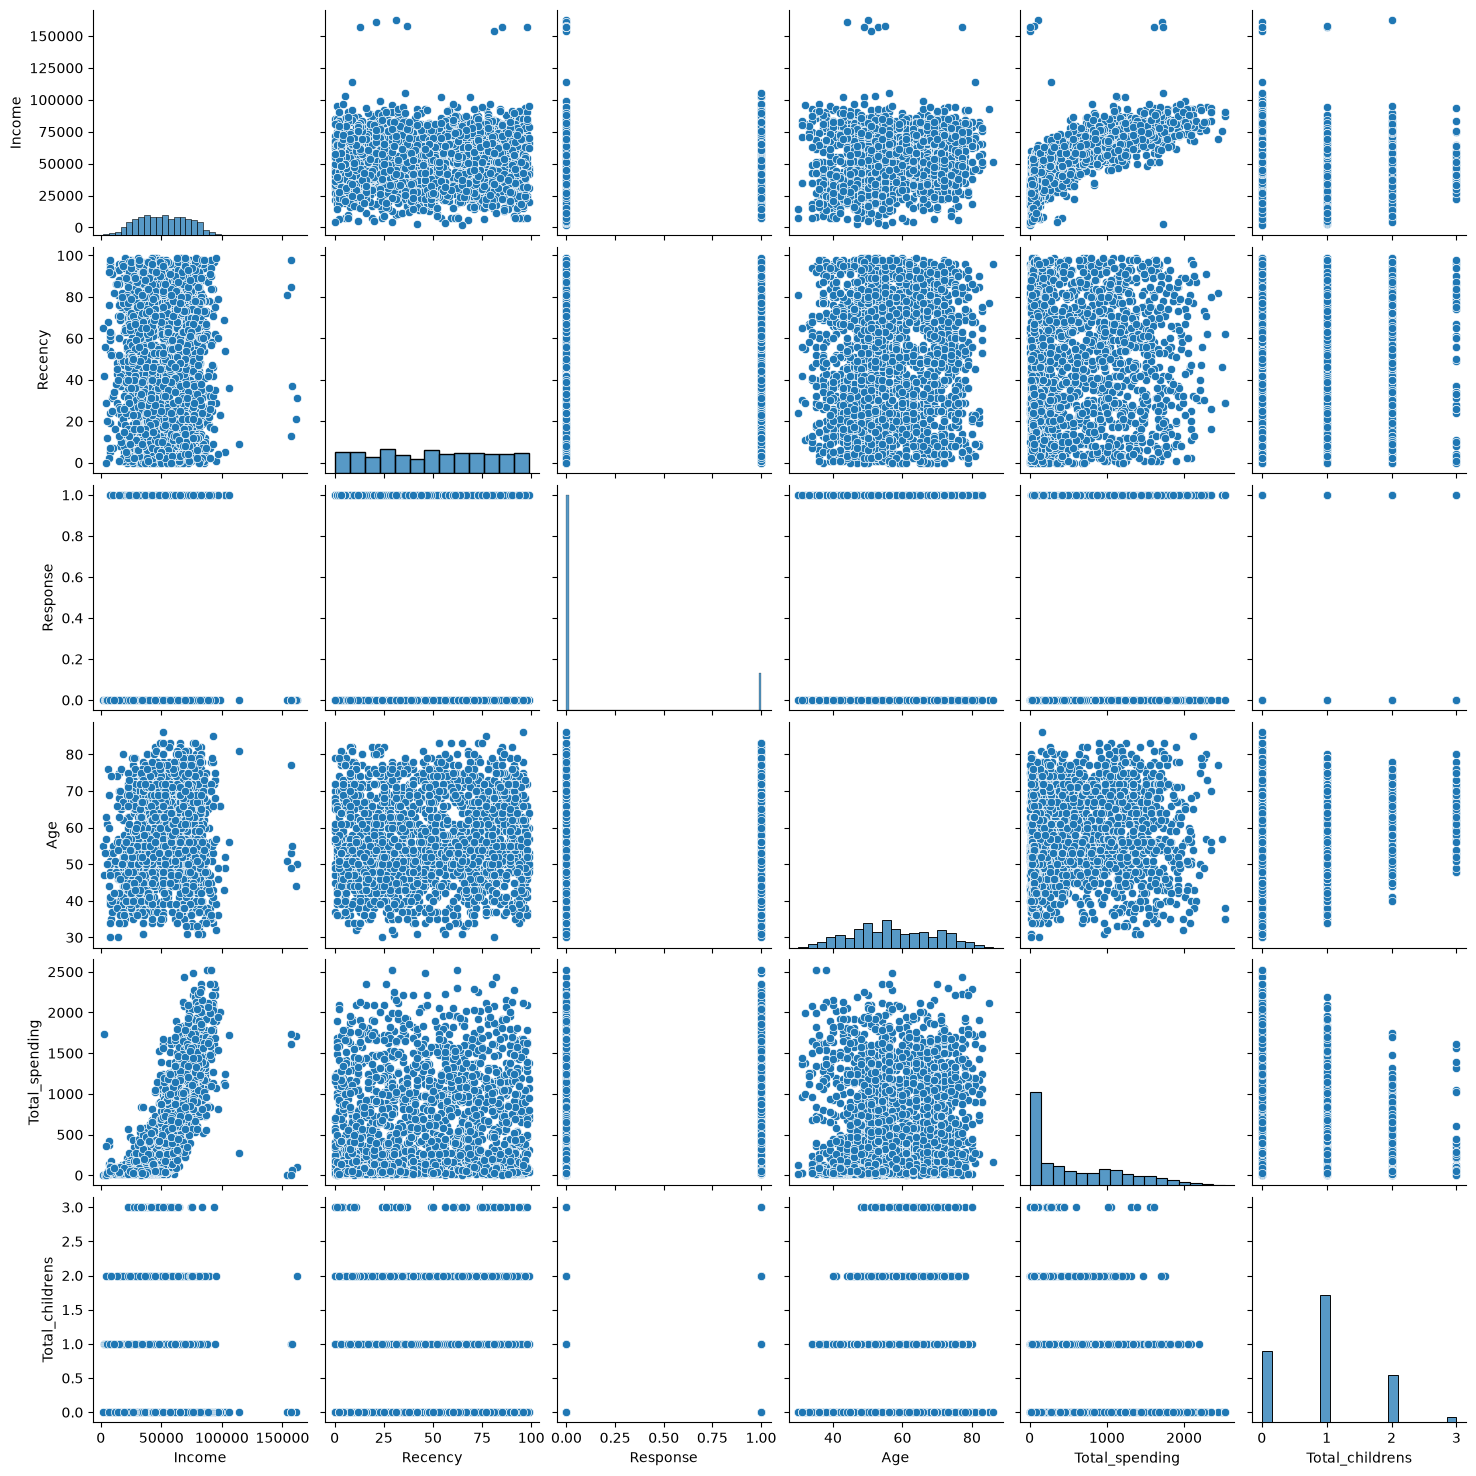

In [74]:
col = [ 'Income', 'Recency', 'Response', 'Age','Total_spending', 'Total_childrens']
sns.pairplot(df[col])

# Heat Mapping

In [75]:
c = df.corr(numeric_only=True)



<Axes: >

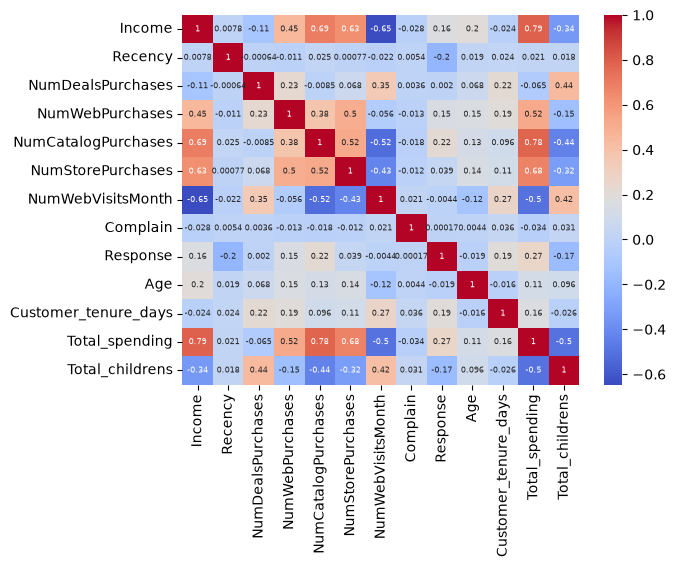

In [82]:
sns.heatmap(
    c,
    annot=True,
    cmap="coolwarm",
    annot_kws={"size" :6}
)

In [ ]:
# here we can compare how things increase with one another

# Encoading

In [83]:
from sklearn.preprocessing import OneHotEncoder

In [90]:
ohe = OneHotEncoder()

cat_col = ["Education" , "Marital_Status"]

enc_col = ohe.fit_transform(df[cat_col])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4472 stored elements and shape (2236, 5)>
  Coords	Values
  (0, 0)	1.0
  (0, 3)	1.0
  (1, 0)	1.0
  (1, 3)	1.0
  (2, 0)	1.0
  (2, 4)	1.0
  (3, 0)	1.0
  (3, 4)	1.0
  (4, 1)	1.0
  (4, 4)	1.0
  (5, 1)	1.0
  (5, 4)	1.0
  (6, 0)	1.0
  (6, 3)	1.0
  (7, 1)	1.0
  (7, 4)	1.0
  (8, 1)	1.0
  (8, 4)	1.0
  (9, 1)	1.0
  (9, 4)	1.0
  (10, 0)	1.0
  (10, 4)	1.0
  (11, 2)	1.0
  (11, 4)	1.0
  (12, 0)	1.0
  :	:
  (2223, 4)	1.0
  (2224, 0)	1.0
  (2224, 3)	1.0
  (2225, 2)	1.0
  (2225, 4)	1.0
  (2226, 0)	1.0
  (2226, 4)	1.0
  (2227, 0)	1.0
  (2227, 3)	1.0
  (2228, 1)	1.0
  (2228, 3)	1.0
  (2229, 0)	1.0
  (2229, 3)	1.0
  (2230, 0)	1.0
  (2230, 4)	1.0
  (2231, 0)	1.0
  (2231, 4)	1.0
  (2232, 1)	1.0
  (2232, 4)	1.0
  (2233, 0)	1.0
  (2233, 3)	1.0
  (2234, 1)	1.0
  (2234, 4)	1.0
  (2235, 1)	1.0
  (2235, 4)	1.0


In [92]:
con_col = pd.DataFrame(enc_col.toarray() , columns = ohe.get_feature_names_out(cat_col) , index = df.index)

In [93]:
df_cleaned = pd.concat([df.drop(columns=cat_col) , con_col] , axis=1)

In [95]:
df_cleaned.shape

(2236, 18)

# Scaling

In [126]:
from sklearn.preprocessing import StandardScaler
X=df_cleaned
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# visualize

In [127]:
from sklearn.decomposition import PCA

In [128]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)


In [129]:
pca.explained_variance_ratio_                # 23.16+11.3 =34.4  is retained data

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

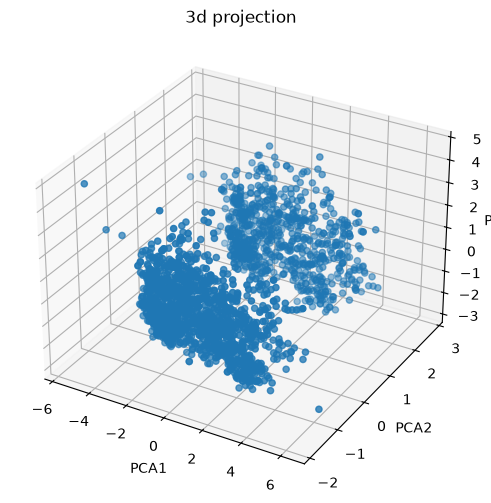

In [134]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111 ,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Best k Value

In [139]:
from sklearn.cluster import KMeans

wcs = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k , random_state = 42)
    kmeans.fit_transform(X_pca)
    wcs.append(kmeans.inertia_)

from kneed import KneeLocator
k = KneeLocator(range(1,11) , wcs , curve="convex" , direction="decreasing")

print("Best k is k=",k.knee)

Best k is k= 4


# clustering

In [149]:
kmeans = KMeans(n_clusters=4, random_state=42)

label = kmeans.fit_predict(X_pca)

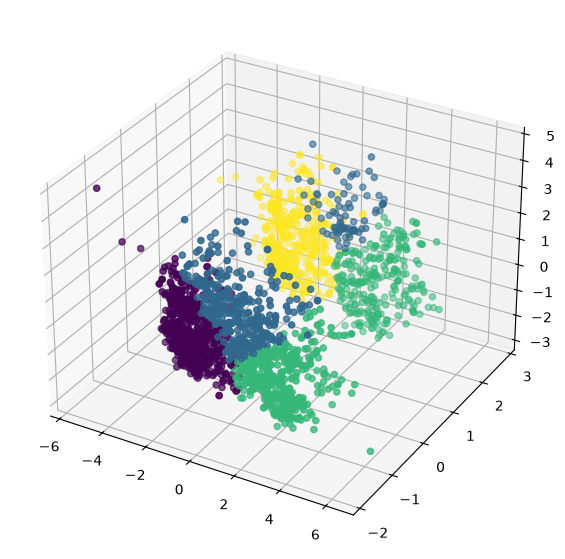

In [154]:
fig = plt.figure(figsize=(7,7))

ax = fig.add_subplot(111 , projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2] , c=label)

In [155]:
# Algomarative clustering

from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters = 4 , linkage="ward")

label_agglo = model.fit_predict(X_pca)

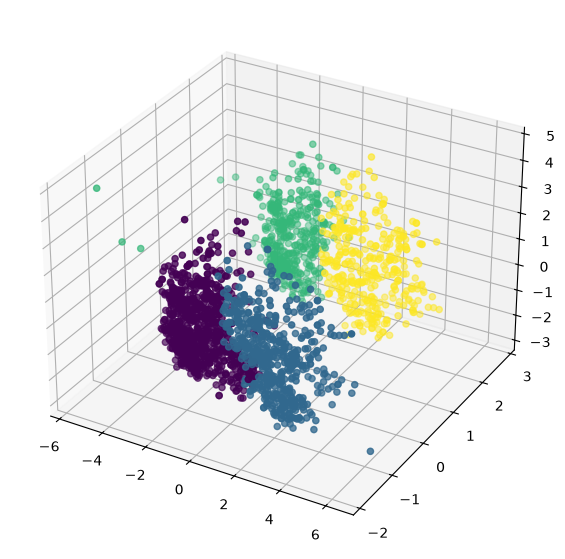

In [156]:
fig = plt.figure(figsize=(7,7))

ax = fig.add_subplot(111 , projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2] , c=label_agglo)

In [160]:
# Agglomerative is best model


array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

# Charactyerization of clusters

In [176]:
df_cleaned["Cluster"] = label_agglo

<Axes: xlabel='Cluster', ylabel='count'>

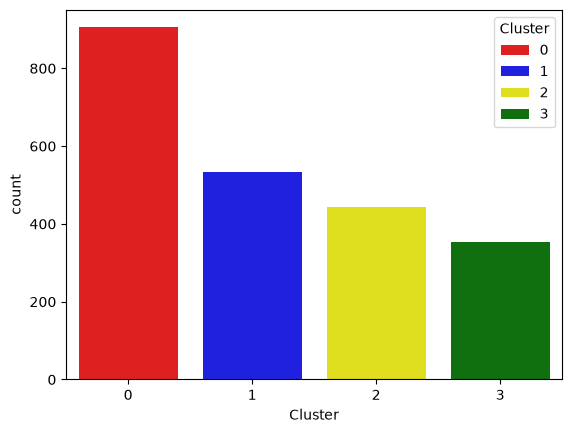

In [177]:
pal = ["red" , "blue" , "yellow" , "green"]

sns.countplot(x=df_cleaned["Cluster"] , palette=pal , hue=df["Cluster"])

<Axes: xlabel='Total_spending', ylabel='Income'>

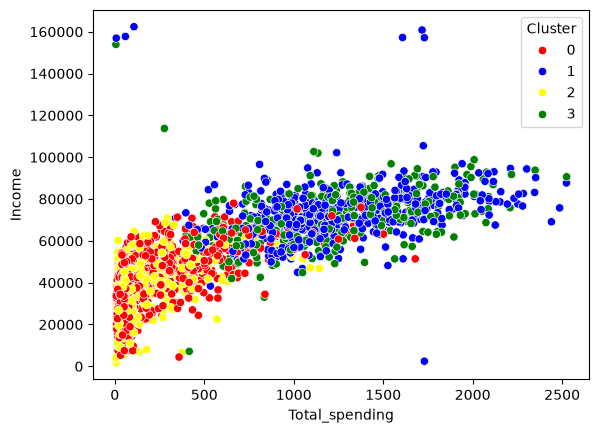

In [178]:
sns.scatterplot(x=df_cleaned["Total_spending"] , y=df_cleaned["Income"] , hue = df_cleaned["Cluster"] ,palette = pal)

In [179]:
df_cleaned

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spending,Total_childrens,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Marital_Status_Alone,Marital_Status_Partner,Cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,0.0,1.0,0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,0.0,1.0,0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,1.0,0.0,3
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,0.0,1.0,1


In [181]:
Summary = df_cleaned.groupby("Cluster").mean()
print(Summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
Cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_tenure_days  Total_spending  \
Cluster         